# 02 - Exploratory Data Analysis
Visualizations and distributions.

In [2]:
import sys
from pathlib import Path

venv_site_packages = Path(r"C:\Aman\Project\customer-churn-prediction\venv\Lib\site-packages")
if venv_site_packages.exists() and str(venv_site_packages) not in sys.path:
    sys.path.insert(0, str(venv_site_packages))

import pandas as pd

In [4]:
from pathlib import Path

df = Path(r"C:\Aman\Project\customer-churn-prediction\data\raw\Telco_customer_churn.xlsx")
print(df.exists())

df = pd.read_excel(df)

True


In [3]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [4]:
df['Churn Reason'].value_counts()

Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Service dissatisfaction                       89
Lack of self-service on Website               88
Extra data charges                            57
Moved                                         53
Limited range of services                     44
Lack of affordable download/upload speed      44
Long distance charges                         44
Poor expertise of phone support               20
Poor expertise of online support              19
Deceased                                       6
Name: c

In [5]:
df.groupby('Contract')['Churn Value'].mean() * 100

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn Value, dtype: float64

## Contract Type vs Churn

### Observation

- Customers with Month-to-Month contracts have the highest churn rate (42.7%).
- Customers with One-Year contracts have significantly lower churn (11.3%).
- Customers with Two-Year contracts have the lowest churn rate (2.8%).

### Business Insight

Long-term contracts improve customer retention by increasing commitment and reducing switching behavior.

### Recommendation

The company should encourage Month-to-Month customers to migrate to longer contract plans through discounts and loyalty programs.

In [6]:
df.groupby('Internet Service')['Churn Value'].mean() * 100

Internet Service
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Churn Value, dtype: float64

## Internet Service vs Churn

### Observation

- Fiber Optic customers show a churn rate of 41.9%.
- DSL customers show a churn rate of 19.0%.
- Customers without internet service have the lowest churn rate (7.4%).

### Business Insight

Fiber Optic customers may have higher expectations regarding speed, reliability, and pricing. Dissatisfaction in these areas can lead to increased churn.

### Recommendation

Investigate customer complaints related to Fiber Optic services and improve service quality or pricing competitiveness.

In [7]:
df.groupby('Tech Support')['Churn Value'].mean() * 100

Tech Support
No                     41.635474
No internet service     7.404980
Yes                    15.166341
Name: Churn Value, dtype: float64

## Tech Support vs Churn

### Observation

- Customers without Tech Support churn at 41.6%.
- Customers with Tech Support churn at only 15.2%.

### Business Insight

Technical assistance plays a major role in customer retention. Customers receiving support are more likely to stay with the company.

### Recommendation

Promote Tech Support packages and improve customer awareness of available support services.

In [8]:
df.groupby('Online Security')['Churn Value'].mean() * 100

Online Security
No                     41.766724
No internet service     7.404980
Yes                    14.611194
Name: Churn Value, dtype: float64

## Online Security vs Churn

### Observation

- Customers without Online Security churn at 41.8%.
- Customers with Online Security churn at only 14.6%.

### Business Insight

Security-related services increase customer trust and perceived value, reducing the likelihood of churn.

### Recommendation

Bundle Online Security features into service packages and encourage adoption among existing customers.

In [9]:
df.groupby('Payment Method')['Churn Value'].mean() * 100

Payment Method
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: Churn Value, dtype: float64

## Payment Method vs Churn

### Observation

- Customers using Electronic Check show the highest churn rate (45.3%).
- Automatic payment methods have significantly lower churn rates (15–17%).

### Business Insight

Customers using automatic payment systems are generally more engaged and experience fewer payment-related issues.

### Recommendation

Encourage customers to switch from Electronic Check to automatic payment methods through incentives and simplified enrollment.

In [10]:
df.groupby('Paperless Billing')['Churn Value'].mean() * 100

Paperless Billing
No     16.330084
Yes    33.565092
Name: Churn Value, dtype: float64

## Paperless Billing vs Churn

### Observation

- Customers using Paperless Billing churn at 33.6%.
- Customers not using Paperless Billing churn at 16.3%.

### Business Insight

Paperless Billing users appear more likely to leave the company. This may be related to customer demographics, service preferences, or plan characteristics.

### Recommendation

Further investigation is required to determine whether Paperless Billing itself contributes to churn or simply correlates with other risk factors.

# Key Findings

1. Month-to-Month customers are the most likely to churn.
2. Fiber Optic customers exhibit higher churn rates than DSL customers.
3. Lack of Tech Support strongly correlates with customer churn.
4. Lack of Online Security strongly correlates with customer churn.
5. Electronic Check users are the highest-risk payment group.
6. Paperless Billing customers show elevated churn rates.
7. Overall churn rate is approximately 26.5%.

# Potential Drivers of Churn

- Short contract duration
- Lack of support services
- Lack of security services
- Electronic payment preferences
- Fiber Optic service dissatisfaction

# Next Steps

- Feature Engineering
- Data Preprocessing
- Model Training
- Churn Prediction Dashboard

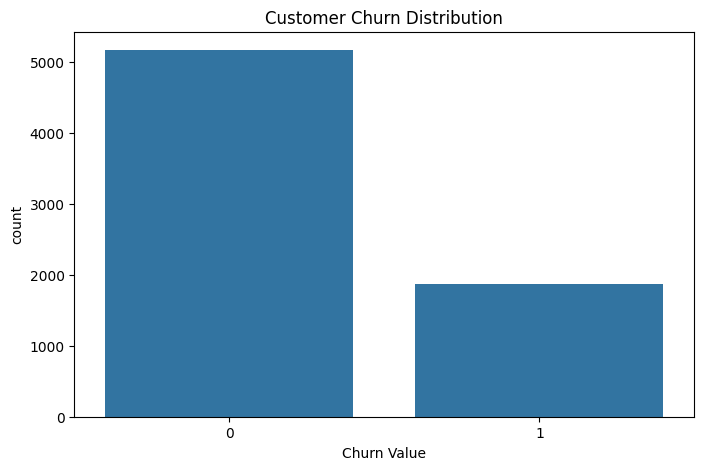

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x='Churn Value', data=df)

plt.title('Customer Churn Distribution')
plt.show()

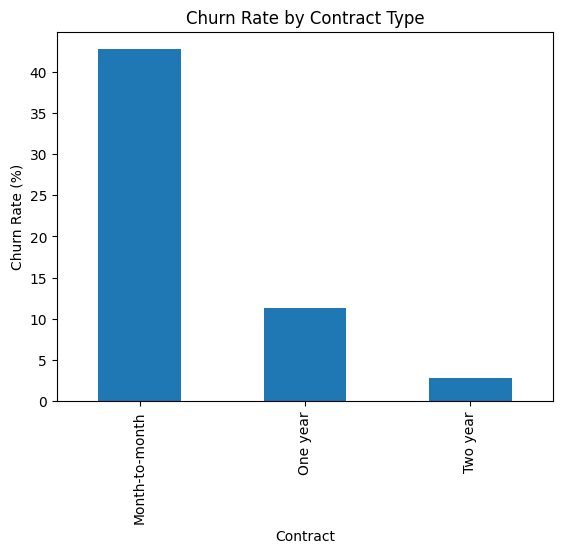

In [6]:
contract_churn = (
    df.groupby('Contract')['Churn Value']
      .mean()
      .sort_values(ascending=False)
      * 100
)

contract_churn.plot(kind='bar')

plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.show()

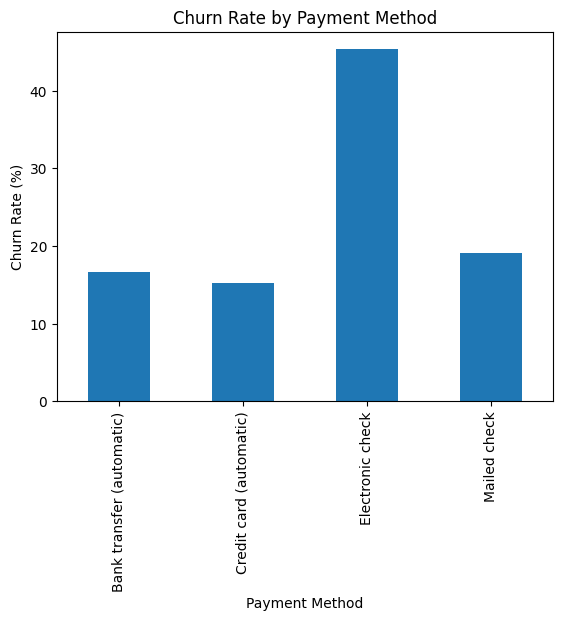

In [7]:
payment_churn = (
    df.groupby('Payment Method')['Churn Value']
      .mean()
      * 100
)

payment_churn.plot(kind='bar')

plt.title('Churn Rate by Payment Method')
plt.ylabel('Churn Rate (%)')
plt.show()

## Key Findings

1. Month-to-month customers have the highest churn rate (42.7%).

2. Fiber optic customers churn more frequently than DSL customers.

3. Customers without tech support show significantly higher churn.

4. Customers without online security show significantly higher churn.

5. Electronic check users exhibit the highest churn rate (45.3%).